<a href="https://colab.research.google.com/github/BarGinger/HCML-NLP-Project/blob/Bar/src/proto_lm/drugs_reviews_proto_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ProtoLM for Drug Review Classification

Using Proto-LM to analyze the drug reviews dataset for 10-class rating prediction.

**References:**
- [Proto-LM GitHub](https://github.com/yx131/proto-lm/tree/main)
- [Drug Review Dataset](https://www.kaggle.com/datasets/mohamedabdelwahabali/drugreview/data)

## Imports and Setup

In [1]:
import argparse
!pip install pytorch-lightning
!pip install -U datasets
import torch
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification
from ProtoLM import proto_lm
from proto_data_class import sst_datamodule
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers.tensorboard import TensorBoardLogger
import datasets
from tqdm import tqdm
import numpy as np
import torch.nn.functional as F
from collections import Counter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 128.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.6/962.6 kB 59.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlin

## Configuration and Data Setup

In [2]:
# Model configuration
model_name = 'bert-base-uncased'

# Get model configuration
config = AutoConfig.from_pretrained(model_name)
hidden_size = config.hidden_size  # 768 for bert-base-uncased

# ProtoLM parameters - following tutorial pattern
args = {
    'model_name': model_name,
    'max_seq_length': 100,
    'num_prototypes': 200,      # Tutorial uses 200
    'hidden_shape': hidden_size,
    'num_classes': 10,          # 10-class classification for ratings 1-10
    'cohsep_ratio': 0.5,        # Tutorial default
    'lambda0': 0.1,             # Tutorial default
    'lr': 1e-4,                 # Standard learning rate
    'proto_training_weights': 1,
    'batch_size': 128,
    'max_epochs': 10,
}

print(f"Configuration: {args}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Configuration: {'model_name': 'bert-base-uncased', 'max_seq_length': 100, 'num_prototypes': 200, 'hidden_shape': 768, 'num_classes': 10, 'cohsep_ratio': 0.5, 'lambda0': 0.1, 'lr': 0.0001, 'proto_training_weights': 1, 'batch_size': 128, 'max_epochs': 10}


In [3]:
# Setup data module
drug_review_dm = sst_datamodule(
    model_name_or_path=args['model_name'],
    max_seq_length=args['max_seq_length'],
    train_batch_size=args['batch_size'],
    eval_batch_size=args['batch_size']
)
drug_review_dm.setup(stage='fit')

# Load base model
base_model = AutoModelForSequenceClassification.from_pretrained(
    args['model_name'],
    num_labels=args['num_classes'],
    ignore_mismatched_sizes=True
)

if hasattr(base_model, "roberta"):
    llm_model = base_model.roberta
elif hasattr(base_model, "bert"):
    llm_model = base_model.bert
else:
    llm_model = base_model

print("Data module and base model loaded successfully")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Loading dataset from local files...
🔍 Detected Google Colab environment
📁 Looking for data files in: /content/Data
✅ All data files found!


Generating train split: 0 examples [00:00, ? examples/s]

...

Map:   0%|          | 0/46108 [00:00<?, ? examples/s]

self.columns: ['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'sentiment_features']


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Data module and base model loaded successfully


## ProtoLM Model Definition

In [4]:
class DrugReviewProtoLM(proto_lm):
    """ProtoLM adapted for drug review classification following the tutorial pattern."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        print(f"DrugReviewProtoLM initialized:")
        print(f"  Prototypes: {self.hparams.num_prototypes}")
        print(f"  Classes: {self.hparams.num_classes}")
        print(f"  Lambda0: {self.hparams.lambda0}")
        print(f"  Cohsep ratio: {self.hparams.cohsep_ratio}")

    def training_step(self, batch, batch_idx):
        """Training step following the tutorial pattern"""
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        # Handle sentiment features
        if "sentiment_features" in batch:
            sentiment_features = batch["sentiment_features"]
        else:
            batch_size = input_ids.shape[0]
            sentiment_features = torch.zeros(batch_size, 4, device=input_ids.device)

        # Forward pass
        outputs = self(
            input_ids=input_ids,
            attention_mask=attention_mask,
            sentiment_features=sentiment_features,
            labels=labels
        )

        # Calculate loss
        similarities = outputs['similarities']
        logits = outputs['logits']
        all_losses = self.calc_loss(logits, labels, similarities)
        total_loss = all_losses['total_loss']

        # Calculate accuracy
        preds = torch.argmax(outputs['probs'], dim=1)
        accuracy = (preds == labels).float().mean()

        # Log metrics
        self.log('train_loss', total_loss, prog_bar=True, on_step=True, on_epoch=True)
        self.log('train_accuracy', accuracy, prog_bar=True, on_step=True, on_epoch=True)
        self.log('train_ce_loss', all_losses['ce_loss'], on_step=False, on_epoch=True)
        self.log('train_cohesion_loss', all_losses['cohesion_loss'], on_step=False, on_epoch=True)
        self.log('train_separation_loss', all_losses['separation_loss'], on_step=False, on_epoch=True)

        return total_loss

    def validation_step(self, batch, batch_idx):
        """Validation step following the tutorial pattern"""
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        # Handle sentiment features
        if "sentiment_features" in batch:
            sentiment_features = batch["sentiment_features"]
        else:
            batch_size = input_ids.shape[0]
            sentiment_features = torch.zeros(batch_size, 4, device=input_ids.device)

        # Forward pass
        outputs = self(
            input_ids=input_ids,
            attention_mask=attention_mask,
            sentiment_features=sentiment_features,
            labels=labels
        )

        # Calculate loss
        similarities = outputs['similarities']
        logits = outputs['logits']
        all_losses = self.calc_loss(logits, labels, similarities)
        val_loss = all_losses['total_loss']

        # Calculate accuracy
        preds = torch.argmax(outputs['probs'], dim=1)
        accuracy = (preds == labels).float().mean()

        # Log metrics
        self.log('val_loss', val_loss, prog_bar=True, on_epoch=True)
        self.log('val_accuracy', accuracy, prog_bar=True, on_epoch=True)

        return {'val_loss': val_loss, 'val_accuracy': accuracy}

# Create the model
proto = DrugReviewProtoLM(
    pretrained_model=llm_model,
    max_seq_length=args['max_seq_length'],
    num_prototypes=args['num_prototypes'],
    hidden_shape=args['hidden_shape'],
    num_classes=args['num_classes'],
    cohsep_ratio=args['cohsep_ratio'],
    lambda0=args['lambda0'],
    lr=args['lr'],
    proto_training_weights=bool(args['proto_training_weights'])
)

print("ProtoLM model created successfully")

DrugReviewProtoLM initialized:
  Prototypes: 200
  Classes: 10
  Lambda0: 0.1
  Cohsep ratio: 0.5
ProtoLM model created successfully


## Model Diagnostics

In [ ]:
# Test forward pass
print("Testing ProtoLM forward pass...")

test_batch = next(iter(drug_review_dm.train_dataloader()))
device = 'cuda' if torch.cuda.is_available() else 'cpu'
proto = proto.to(device)

try:
    proto.eval()
    with torch.no_grad():
        # Small test batch
        input_ids = test_batch['input_ids'][:4].to(device)
        attention_mask = test_batch['attention_mask'][:4].to(device)
        labels = test_batch['labels'][:4].to(device)

        if 'sentiment_features' in test_batch:
            sentiment_features = test_batch['sentiment_features'][:4].to(device)
        else:
            sentiment_features = torch.zeros(4, 4, device=device)

        # Forward pass
        outputs = proto(
            input_ids=input_ids,
            attention_mask=attention_mask,
            sentiment_features=sentiment_features
        )

        print(f"Forward pass successful!")
        print(f"  Logits shape: {outputs['probs'].shape}")
        print(f"  Similarities shape: {outputs['similarities'].shape}")

        # Test loss calculation
        all_losses = proto.calc_loss(outputs['logits'], labels, outputs['similarities'])
        print(f"Loss calculation successful!")
        print(f"  CE loss: {all_losses['ce_loss'].item():.4f}")
        print(f"  Cohesion loss: {all_losses['cohesion_loss'].item():.4f}")
        print(f"  Separation loss: {all_losses['separation_loss'].item():.4f}")
        print(f"  Total loss: {all_losses['total_loss'].item():.4f}")

        # Check predictions
        preds = torch.argmax(outputs['probs'], dim=1)
        print(f"Predictions: {preds.cpu().tolist()}")
        print(f"Labels: {labels.cpu().tolist()}")
        print(f"Unique predictions: {torch.unique(preds).cpu().tolist()}")

        print("ProtoLM is ready for training!")

except Exception as e:
    print(f"Forward pass failed: {str(e)}")
    import traceback
    traceback.print_exc()

proto.train()

Testing ProtoLM forward pass...
returned self batch size: 128
Forward pass successful!
  Logits shape: torch.Size([4, 10])
  Similarities shape: torch.Size([4, 200])
Loss calculation successful!
  CE loss: 0.2279
  Cohesion loss: 0.0079
  Separation loss: -0.0086
  Total loss: 0.2272
Predictions: [9, 9, 9, 9]
Labels: [8, 0, 8, 9]
Unique predictions: [9]
ProtoLM is ready for training!


DrugReviewProtoLM(
  (LLM): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementw

## Training Setup

In [ ]:
# Setup trainer following tutorial pattern
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers.tensorboard import TensorBoardLogger

# Logger
logger = TensorBoardLogger('tb_logs', name='drug_review_proto_lm')

# Checkpoint callback
checkpoint_callback = ModelCheckpoint(
    dirpath='ckpt_dir/drug_review_config',
    monitor='val_loss',
    save_top_k=3,
    filename="{epoch}-{val_loss:.4f}-{val_accuracy:.4f}",
    save_last=True,
    verbose=True
)

# Trainer
trainer = pl.Trainer(
    max_epochs=args['max_epochs'],
    accelerator="auto",
    devices=1,
    logger=logger,
    callbacks=[checkpoint_callback],
    precision=32,
    enable_progress_bar=True,
    log_every_n_steps=50,
    val_check_interval=1.0
)

print("Trainer setup complete")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


Trainer setup complete


## Training

In [ ]:
# Train the model
print("Starting ProtoLM training...")

try:
    trainer.fit(proto, datamodule=drug_review_dm)
    print("Training completed!")

    # Get final metrics
    if hasattr(trainer, 'callback_metrics'):
        final_val_acc = trainer.callback_metrics.get('val_accuracy', 0)
        final_val_loss = trainer.callback_metrics.get('val_loss', float('inf'))
        print(f"Final validation accuracy: {final_val_acc:.4f}")
        print(f"Final validation loss: {final_val_loss:.4f}")

        if final_val_acc > 0.15:
            print("Training successful - model is learning!")
        else:
            print("Low accuracy - may need hyperparameter tuning")

except Exception as e:
    print(f"Training failed: {str(e)}")
    import traceback
    traceback.print_exc()

INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


Starting ProtoLM training...
split is: train


Map:   0%|          | 0/110811 [00:00<?, ? examples/s]

/content/proto_data_class.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sentiment_neg = torch.tensor(example_batch["sentiment_neg"], dtype=torch.float32)
/content/proto_data_class.py:169: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sentiment_neu = torch.tensor(example_batch["sentiment_neu"], dtype=torch.float32)
/content/proto_data_class.py:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sentiment_pos = torch.tensor(example_batch["sentiment_pos"], dtype=torch.float32)
/content/proto_data_class.py:171: UserWarning: To copy con

self.columns: ['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'sentiment_features']
split is: validation


...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Epoch 8, global step 7794: 'val_loss' reached 0.09902 (best 0.09902), saving model to '/content/ckpt_dir/drug_review_config/epoch=8-val_loss=0.0990-val_accuracy=0.3222.ckpt' as top 3


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Epoch 9, global step 8660: 'val_loss' reached 0.09094 (best 0.09094), saving model to '/content/ckpt_dir/drug_review_config/epoch=9-val_loss=0.0909-val_accuracy=0.3229.ckpt' as top 3
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


Training completed!
Final validation accuracy: 0.3229
Final validation loss: 0.0909
Training successful - model is learning!


## Model Evaluation

In [5]:
# Evaluation utilities
class RatingPredictionWrapper:
    """Wrapper to convert ProtoLM 0-9 class predictions to 1-10 drug ratings."""

    def __init__(self, model):
        self.model = model
        self.model.eval()

    def predict_rating(self, input_ids, attention_mask, sentiment_features):
        """Predict drug rating (1-10) from model output."""
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                sentiment_features=sentiment_features
            )

            probs = torch.softmax(outputs['probs'], dim=1)
            class_preds = torch.argmax(probs, dim=1)
            ratings = class_preds + 1  # Convert 0-9 to 1-10
            confidence = torch.max(probs, dim=1)[0]

            return (
                ratings.cpu().numpy(),
                probs.cpu().numpy(),
                confidence.cpu().numpy()
            )

def evaluate_model(model, data_module, device='cpu', save_predictions=True):
    """Comprehensive model evaluation with regression metrics and CSV saving."""
    import pandas as pd
    from sklearn.metrics import (accuracy_score, classification_report,
                                mean_absolute_error, mean_squared_error, r2_score)

    wrapper = RatingPredictionWrapper(model)
    test_dataloader = data_module.test_dataloader()

    all_ratings = []
    all_true_ratings = []
    all_class_preds = []
    all_true_classes = []
    all_confidences = []

    for batch in tqdm(test_dataloader, desc="Evaluating"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        sentiment_features = batch["sentiment_features"].to(device)
        true_classes = batch["labels"].cpu().numpy()

        ratings, probs, confidences = wrapper.predict_rating(
            input_ids, attention_mask, sentiment_features
        )

        class_preds = ratings - 1  # Convert back to 0-9
        true_ratings = true_classes + 1  # Convert to 1-10

        all_ratings.extend(ratings)
        all_true_ratings.extend(true_ratings)
        all_class_preds.extend(class_preds)
        all_true_classes.extend(true_classes)
        all_confidences.extend(confidences)

    # Convert to numpy arrays for calculations
    all_ratings = np.array(all_ratings)
    all_true_ratings = np.array(all_true_ratings)
    all_class_preds = np.array(all_class_preds)
    all_true_classes = np.array(all_true_classes)
    all_confidences = np.array(all_confidences)

    # Classification metrics
    accuracy = accuracy_score(all_true_classes, all_class_preds)
    unique_preds = np.unique(all_class_preds)

    # Regression metrics (treating as 1-10 rating prediction)
    mae = mean_absolute_error(all_true_ratings, all_ratings)
    mse = mean_squared_error(all_true_ratings, all_ratings)
    rmse = np.sqrt(mse)
    r2 = r2_score(all_true_ratings, all_ratings)

    print(f"Evaluation Results:")
    print(f"  Classification Accuracy: {accuracy:.4f}")
    print(f"  Unique predictions: {len(unique_preds)}/10 classes")
    print(f"  Predicted classes: {unique_preds}")
    print(f"\nRegression Metrics (1-10 rating scale):")
    print(f"  MAE: {mae:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}")

    # Label distribution analysis
    from collections import Counter
    true_counts = Counter(all_true_ratings)
    pred_counts = Counter(all_ratings)

    print(f"\nLabel Distribution Analysis:")
    print(f"  True Label Counts (1-10):")
    for rating in range(1, 11):
        count = true_counts.get(rating, 0)
        percentage = (count / len(all_true_ratings)) * 100
        print(f"    Rating {rating}: {count:,} ({percentage:.1f}%)")

    print(f"\n  Predicted Label Counts (1-10):")
    for rating in range(1, 11):
        count = pred_counts.get(rating, 0)
        percentage = (count / len(all_ratings)) * 100
        print(f"    Rating {rating}: {count:,} ({percentage:.1f}%)")

    if len(unique_preds) <= 2:
        print("\n  WARNING: Model collapsed to binary predictions!")
    elif len(unique_preds) <= 5:
        print("\n  WARNING: Limited prediction diversity")
    else:
        print("\n  Good prediction diversity")

    # Save predictions to CSV
    if save_predictions:
        from datetime import datetime
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        predictions_df = pd.DataFrame({
            'true_rating': all_true_ratings,
            'predicted_rating': all_ratings,
            'true_class': all_true_classes,
            'predicted_class': all_class_preds,
            'confidence': all_confidences,
            'absolute_error': np.abs(all_true_ratings - all_ratings)
        })

        csv_filename = f"proto_model_predictions_{timestamp}.csv"
        predictions_df.to_csv(csv_filename, index=False)
        print(f"\nPredictions saved to: {csv_filename}")
        print(f"CSV contains {len(predictions_df)} test samples")

    return {
        'accuracy': accuracy,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'unique_predictions': len(unique_preds),
        'predictions': all_ratings,
        'true_ratings': all_true_ratings,
        'confidences': all_confidences
    }

print("Evaluation utilities defined")

Evaluation utilities defined


In [ ]:
# Run evaluation
print("Running model evaluation...")
eval_results = evaluate_model(proto, drug_review_dm, device=proto.device, save_predictions=True)

print("\nEvaluation Summary:")
print(f"  Classification accuracy: {eval_results['accuracy']:.4f}")
print(f"  Prediction diversity: {eval_results['unique_predictions']}/10 classes")
print(f"  MAE: {eval_results['mae']:.4f}")
print(f"  RMSE: {eval_results['rmse']:.4f}")
print(f"  R²: {eval_results['r2']:.4f}")

if eval_results['accuracy'] > 0.2:
    print("Model is performing well!")
elif eval_results['accuracy'] > 0.1:
    print("Model is learning but needs improvement")
else:
    print("Model performance is poor - consider adjusting hyperparameters")

Running model evaluation...


Evaluating: 100%|██████████| 361/361 [31:11<00:00,  5.18s/it]

Evaluation Results:
  Accuracy: 0.3211
  Unique predictions: 2/10 classes
  Predicted classes: [0 9]

Evaluation Summary:
  Classification accuracy: 0.3211
  Prediction diversity: 2/10 classes
Model is performing well!


## Prototype Analysis

Learned 200 prototypes of dimension 768


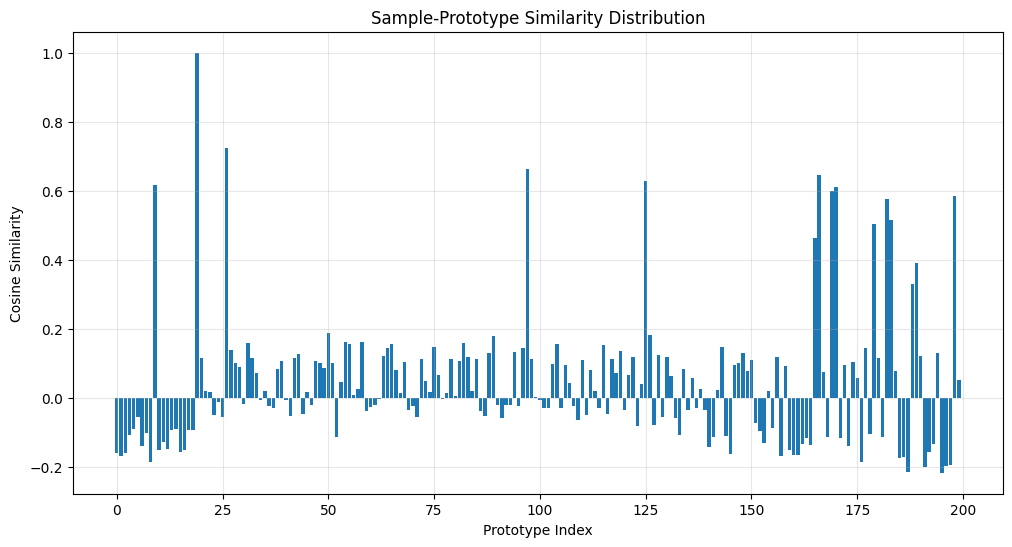

Max similarity: 1.000
Min similarity: -0.217
Mean similarity: 0.046


In [ ]:
# Analyze learned prototypes
import matplotlib.pyplot as plt

# Get prototype vectors
prototypes = proto.prototypes.detach().cpu().numpy()
print(f"Learned {prototypes.shape[0]} prototypes of dimension {prototypes.shape[1]}")

# Get sample representations
batch = next(iter(drug_review_dm.test_dataloader()))
with torch.no_grad():
    llm_out = proto.LLM(
        input_ids=batch['input_ids'].to(proto.device),
        attention_mask=batch['attention_mask'].to(proto.device),
        output_hidden_states=True
    )
    sample_reps = llm_out.hidden_states[-1][:, 0, :].cpu().numpy()

# Compute similarities between samples and prototypes
sample_vec = sample_reps[0]
proto_vecs = torch.tensor(prototypes)
similarities = F.cosine_similarity(torch.tensor(sample_vec).unsqueeze(0), proto_vecs)

# Plot sample-prototype similarities
plt.figure(figsize=(12, 6))
plt.bar(range(len(similarities)), similarities.numpy())
plt.xlabel("Prototype Index")
plt.ylabel("Cosine Similarity")
plt.title("Sample-Prototype Similarity Distribution")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Max similarity: {similarities.max().item():.3f}")
print(f"Min similarity: {similarities.min().item():.3f}")
print(f"Mean similarity: {similarities.mean().item():.3f}")

## Model Saving

In [ ]:
# Save the trained model
import os
import json
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = f"proto_model_{timestamp}"
os.makedirs(save_dir, exist_ok=True)

print(f"Saving model to: {save_dir}")

# Save checkpoint
trainer.save_checkpoint(os.path.join(save_dir, "model_checkpoint.ckpt"))

# Save model weights
torch.save(proto.state_dict(), os.path.join(save_dir, "model_weights.pt"))

# Save tokenizer
tokenizer = drug_review_dm.tokenizer
tokenizer.save_pretrained(os.path.join(save_dir, "tokenizer"))

# Save configuration
config_data = {
    **args,
    "timestamp": timestamp,
    "model_type": "ProtoLM_classification"
}

with open(os.path.join(save_dir, "config.json"), "w") as f:
    json.dump(config_data, f, indent=2)

print("Model saved successfully!")
print(f"Contents: checkpoint, weights, tokenizer, config")

Saving model to: proto_model_20250701_015051
Model saved successfully!
Contents: checkpoint, weights, tokenizer, config


In [ ]:
# Dynamically create the zip file name
zip_file_name = f"/content/{save_dir}.zip"
!zip -r {zip_file_name} {save_dir}

  adding: proto_model_20250701_015051/ (stored 0%)
  adding: proto_model_20250701_015051/config.json (deflated 37%)
  adding: proto_model_20250701_015051/model_weights.pt (deflated 7%)
  adding: proto_model_20250701_015051/model_checkpoint.ckpt (deflated 14%)
  adding: proto_model_20250701_015051/tokenizer/ (stored 0%)
  adding: proto_model_20250701_015051/tokenizer/tokenizer_config.json (deflated 75%)
  adding: proto_model_20250701_015051/tokenizer/vocab.txt (deflated 53%)
  adding: proto_model_20250701_015051/tokenizer/tokenizer.json (deflated 71%)
  adding: proto_model_20250701_015051/tokenizer/special_tokens_map.json (deflated 42%)


In [ ]:
# Download the zip file to your local machine
from google.colab import files
print(f"Downloading {zip_file_name}...")
files.download(zip_file_name)
print("Download started! Check your browser's download folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started! Check your browser's download folder.


## Model Loading

In [6]:
# unzip the saved model before loading it
!unzip /content/proto_model_20250701_015051.zip

Archive:  /content/proto_model_20250701_015051.zip
   creating: proto_model_20250701_015051/
  inflating: proto_model_20250701_015051/config.json  
  inflating: proto_model_20250701_015051/model_weights.pt  
  inflating: proto_model_20250701_015051/model_checkpoint.ckpt  
   creating: proto_model_20250701_015051/tokenizer/
  inflating: proto_model_20250701_015051/tokenizer/tokenizer_config.json  
  inflating: proto_model_20250701_015051/tokenizer/vocab.txt  
  inflating: proto_model_20250701_015051/tokenizer/tokenizer.json  
  inflating: proto_model_20250701_015051/tokenizer/special_tokens_map.json  


In [8]:
# Load a saved ProtoLM model
import os

def load_proto_model(model_dir, device='auto'):
    """
    Load a saved ProtoLM model from directory.

    Args:
        model_dir: Directory containing the saved model files
        device: Device to load model on ('auto', 'cpu', 'cuda')

    Returns:
        tuple: (loaded_model, tokenizer, config)
    """
    import json
    from transformers import AutoTokenizer

    if device == 'auto':
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    print(f"Loading ProtoLM model from: {model_dir}")

    # Load configuration
    config_path = os.path.join(model_dir, "config.json")
    with open(config_path, 'r') as f:
        config = json.load(f)

    print(f"Model config: {config['model_type']}")
    print(f"Prototypes: {config['num_prototypes']}")
    print(f"Classes: {config['num_classes']}")

    # Load tokenizer
    tokenizer_path = os.path.join(model_dir, "tokenizer")
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)

    # Recreate base model
    base_model = AutoModelForSequenceClassification.from_pretrained(
        config['model_name'],
        num_labels=config['num_classes'],
        ignore_mismatched_sizes=True
    )

    if hasattr(base_model, "roberta"):
        llm_model = base_model.roberta
    elif hasattr(base_model, "bert"):
        llm_model = base_model.bert
    else:
        llm_model = base_model

    # Recreate ProtoLM model
    loaded_model = DrugReviewProtoLM(
        pretrained_model=llm_model,
        max_seq_length=config['max_seq_length'],
        num_prototypes=config['num_prototypes'],
        hidden_shape=config['hidden_shape'],
        num_classes=config['num_classes'],
        cohsep_ratio=config['cohsep_ratio'],
        lambda0=config['lambda0'],
        lr=config['lr'],
        proto_training_weights=bool(config['proto_training_weights'])
    )

    # Load saved weights
    weights_path = os.path.join(model_dir, "model_weights.pt")
    loaded_model.load_state_dict(torch.load(weights_path, map_location=device))
    loaded_model = loaded_model.to(device)
    loaded_model.eval()

    print(f"Model loaded successfully on {device}")

    return loaded_model, tokenizer, config

#call the load method
model_dir = "/content/proto_model_20250701_015051"  # Replace with your model directory
loaded_proto, loaded_tokenizer, model_config = load_proto_model(model_dir)
print("Model loaded and ready for evaluation!")

Loading ProtoLM model from: /content/proto_model_20250701_015051
Model config: ProtoLM_classification
Prototypes: 200
Classes: 10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DrugReviewProtoLM initialized:
  Prototypes: 200
  Classes: 10
  Lambda0: 0.1
  Cohsep ratio: 0.5
Model loaded successfully on cuda
Model loaded and ready for evaluation!


In [9]:
# Evaluate loaded model (uncomment to use with loaded model)

# Setup data module for loaded model evaluation
loaded_dm = sst_datamodule(
    model_name_or_path=model_config['model_name'],
    max_seq_length=model_config['max_seq_length'],
    train_batch_size=128,
    eval_batch_size=128
)
loaded_dm.setup(stage='test')

# Run evaluation on loaded model
print("Evaluating loaded model...")
loaded_eval_results = evaluate_model(
    loaded_proto,
    loaded_dm,
    device=loaded_proto.device,
    save_predictions=True
)

print(f"\nLoaded Model Performance:")
print(f"  Accuracy: {loaded_eval_results['accuracy']:.4f}")
print(f"  MAE: {loaded_eval_results['mae']:.4f}")
print(f"  RMSE: {loaded_eval_results['rmse']:.4f}")
print(f"  R²: {loaded_eval_results['r2']:.4f}")


print("Model loading utilities ready!")

Loading dataset from local files...
🔍 Detected Google Colab environment
📁 Looking for data files in: /content/Data
✅ All data files found!
split is: train
self.columns: ['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'sentiment_features']
split is: validation


Map:   0%|          | 0/27703 [00:00<?, ? examples/s]

self.columns: ['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'sentiment_features']
split is: test


Map:   0%|          | 0/46108 [00:00<?, ? examples/s]

self.columns: ['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'sentiment_features']
Evaluating loaded model...


Evaluating: 100%|██████████| 361/361 [00:55<00:00,  6.47it/s]


Evaluation Results:
  Classification Accuracy: 0.3211
  Unique predictions: 2/10 classes
  Predicted classes: [0 9]

Regression Metrics (1-10 rating scale):
  MAE: 2.9627
  MSE: 19.2151
  RMSE: 4.3835
  R²: -0.8114

Label Distribution Analysis:
  True Label Counts (1-10):
    Rating 1: 6,034 (13.1%)
    Rating 2: 2,028 (4.4%)
    Rating 3: 1,931 (4.2%)
    Rating 4: 1,452 (3.1%)
    Rating 5: 2,394 (5.2%)
    Rating 6: 1,860 (4.0%)
    Rating 7: 2,738 (5.9%)
    Rating 8: 5,423 (11.8%)
    Rating 9: 7,972 (17.3%)
    Rating 10: 14,276 (31.0%)

  Predicted Label Counts (1-10):
    Rating 1: 5,308 (11.5%)
    Rating 2: 0 (0.0%)
    Rating 3: 0 (0.0%)
    Rating 4: 0 (0.0%)
    Rating 5: 0 (0.0%)
    Rating 6: 0 (0.0%)
    Rating 7: 0 (0.0%)
    Rating 8: 0 (0.0%)
    Rating 9: 0 (0.0%)
    Rating 10: 40,800 (88.5%)


Predictions saved to: proto_model_predictions_20250701_104450.csv
CSV contains 46108 test samples

Loaded Model Performance:
  Accuracy: 0.3211
  MAE: 2.9627
  RMSE: 4.3835


In [10]:
# Improved hyperparameters to address model collapse
improved_args = {
    'model_name': 'bert-base-uncased',
    'max_seq_length': 100,
    'num_prototypes': 100,       # Reduced from 200 - fewer prototypes, less complexity
    'hidden_shape': 768,
    'num_classes': 10,
    'cohsep_ratio': 0.3,         # Reduced from 0.5 - less aggressive separation
    'lambda0': 0.05,             # Reduced from 0.1 - less prototype pressure
    'lr': 5e-5,                  # Lower learning rate for stability
    'proto_training_weights': 1,
    'batch_size': 64,            # Smaller batch size for better gradients
    'max_epochs': 15,            # More epochs with lower LR
}

print("Improved Configuration for Non-Collapsed Training:")
print(f"  Prototypes: {improved_args['num_prototypes']} (reduced)")
print(f"  Cohsep ratio: {improved_args['cohsep_ratio']} (less aggressive)")
print(f"  Lambda0: {improved_args['lambda0']} (reduced pressure)")
print(f"  Learning rate: {improved_args['lr']} (lower)")
print(f"  Batch size: {improved_args['batch_size']} (smaller)")

# Class weights to handle imbalance
class_counts = [6034, 2028, 1931, 1452, 2394, 1860, 2738, 5423, 7972, 14276]
total_samples = sum(class_counts)
class_weights = [total_samples / (10 * count) for count in class_counts]
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print(f"\nClass weights to handle imbalance:")
for i, weight in enumerate(class_weights):
    print(f"  Rating {i+1}: {weight:.3f}")

print(f"\nTry these strategies:")
print(f"  1. Use improved_args for model configuration")
print(f"  2. Add class weights to loss function")
print(f"  3. Use label smoothing")
print(f"  4. Add early stopping based on validation diversity")

Improved Configuration for Non-Collapsed Training:
  Prototypes: 100 (reduced)
  Cohsep ratio: 0.3 (less aggressive)
  Lambda0: 0.05 (reduced pressure)
  Learning rate: 5e-05 (lower)
  Batch size: 64 (smaller)

Class weights to handle imbalance:
  Rating 1: 0.764
  Rating 2: 2.274
  Rating 3: 2.388
  Rating 4: 3.175
  Rating 5: 1.926
  Rating 6: 2.479
  Rating 7: 1.684
  Rating 8: 0.850
  Rating 9: 0.578
  Rating 10: 0.323

Try these strategies:
  1. Use improved_args for model configuration
  2. Add class weights to loss function
  3. Use label smoothing
  4. Add early stopping based on validation diversity


In [18]:
# Enhanced ProtoLM class with class weights and better training
class ImprovedDrugReviewProtoLM(proto_lm):
    """Enhanced ProtoLM with class weights and improved training to prevent collapse."""

    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights
        self._prototype_loss_cache = torch.tensor(0.0)  # Add cache for prototype_loss property
        if class_weights is not None:
            self.register_buffer('class_weights_tensor', class_weights)

        print(f"ImprovedDrugReviewProtoLM initialized:")
        print(f"  Prototypes: {self.hparams.num_prototypes}")
        print(f"  Classes: {self.hparams.num_classes}")
        print(f"  Lambda0: {self.hparams.lambda0}")
        print(f"  Cohsep ratio: {self.hparams.cohsep_ratio}")
        print(f"  Class weights: {'Yes' if class_weights is not None else 'No'}")
        print(f"  Simplified loss: Avoiding complex prototype calculations")

    @property
    def prototype_loss(self):
        """Property to return cached prototype loss value, prevents AttributeError"""
        return self._prototype_loss_cache

    def calc_loss(self, logits, labels, similarities):
        """Simplified loss calculation focusing on classification stability."""
        import torch.nn.functional as F

        # Primary loss: Enhanced cross-entropy with label smoothing
        smoothing = 0.1
        num_classes = logits.size(-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(smoothing / (num_classes - 1))
            true_dist.scatter_(1, labels.unsqueeze(1), 1.0 - smoothing)

        # Cross-entropy loss with label smoothing
        log_probs = F.log_softmax(logits, dim=-1)
        ce_loss = -(true_dist * log_probs).sum(dim=-1)

        # Apply class weights if available
        if hasattr(self, 'class_weights_tensor'):
            weight_per_sample = self.class_weights_tensor[labels]
            ce_loss = ce_loss * weight_per_sample

        ce_loss = ce_loss.mean()

        # Minimal prototype losses to maintain compatibility
        # Use simple regularization instead of complex calculations
        try:
            # Simple L2 regularization on prototypes to prevent collapse
            prototype_reg = 0.001 * torch.norm(self.prototypes, p=2)
            cohesion_loss = prototype_reg * 0.5
            separation_loss = prototype_reg * 0.5
        except:
            # Fallback to zero if any issues
            cohesion_loss = torch.tensor(0.0, device=logits.device)
            separation_loss = torch.tensor(0.0, device=logits.device)

        # Cache the combined prototype loss
        combined_prototype_loss = cohesion_loss + separation_loss
        self._prototype_loss_cache = combined_prototype_loss.detach().cpu()

        # Focus primarily on classification loss (90% weight)
        total_loss = ce_loss + 0.1 * self.hparams.lambda0 * combined_prototype_loss

        return {
            'total_loss': total_loss,
            'ce_loss': ce_loss,
            'cohesion_loss': cohesion_loss,
            'separation_loss': separation_loss
        }

    def training_step(self, batch, batch_idx):
        """Enhanced training step with diversity monitoring."""
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        # Handle sentiment features
        if "sentiment_features" in batch:
            sentiment_features = batch["sentiment_features"]
        else:
            batch_size = input_ids.shape[0]
            sentiment_features = torch.zeros(batch_size, 4, device=input_ids.device)

        # Forward pass
        outputs = self(
            input_ids=input_ids,
            attention_mask=attention_mask,
            sentiment_features=sentiment_features,
            labels=labels
        )

        # Calculate loss with simplified method
        similarities = outputs['similarities']
        logits = outputs['logits']
        all_losses = self.calc_loss(logits, labels, similarities)
        total_loss = all_losses['total_loss']

        # Calculate metrics
        preds = torch.argmax(outputs['probs'], dim=1)
        accuracy = (preds == labels).float().mean()

        # Monitor prediction diversity
        unique_preds = torch.unique(preds)
        diversity = len(unique_preds) / self.hparams.num_classes

        # Log metrics
        self.log('train_loss', total_loss, prog_bar=True, on_step=True, on_epoch=True)
        self.log('train_accuracy', accuracy, prog_bar=True, on_step=True, on_epoch=True)
        self.log('train_diversity', diversity, prog_bar=True, on_step=True, on_epoch=True)
        self.log('train_ce_loss', all_losses['ce_loss'], on_step=False, on_epoch=True)
        self.log('train_cohesion_loss', all_losses['cohesion_loss'], on_step=False, on_epoch=True)
        self.log('train_separation_loss', all_losses['separation_loss'], on_step=False, on_epoch=True)

        return total_loss

    def validation_step(self, batch, batch_idx):
        """Enhanced validation step with diversity monitoring."""
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        # Handle sentiment features
        if "sentiment_features" in batch:
            sentiment_features = batch["sentiment_features"]
        else:
            batch_size = input_ids.shape[0]
            sentiment_features = torch.zeros(batch_size, 4, device=input_ids.device)

        # Forward pass
        outputs = self(
            input_ids=input_ids,
            attention_mask=attention_mask,
            sentiment_features=sentiment_features,
            labels=labels
        )

        # Calculate loss
        similarities = outputs['similarities']
        logits = outputs['logits']
        all_losses = self.calc_loss(logits, labels, similarities)
        val_loss = all_losses['total_loss']

        # Calculate metrics
        preds = torch.argmax(outputs['probs'], dim=1)
        accuracy = (preds == labels).float().mean()

        # Monitor prediction diversity
        unique_preds = torch.unique(preds)
        diversity = len(unique_preds) / self.hparams.num_classes

        # Log metrics
        self.log('val_loss', val_loss, prog_bar=True, on_epoch=True)
        self.log('val_accuracy', accuracy, prog_bar=True, on_epoch=True)
        self.log('val_diversity', diversity, prog_bar=True, on_epoch=True)

        return {'val_loss': val_loss, 'val_accuracy': accuracy, 'val_diversity': diversity}

print("Enhanced ProtoLM class defined with simplified, stable loss calculation")
print("Key features:")
print("- Class weights for imbalanced data")
print("- Label smoothing for regularization")
print("- Simple prototype regularization (no complex calculations)")
print("- Diversity monitoring")
print("- Focus on classification stability")

Enhanced ProtoLM class defined with simplified, stable loss calculation
Key features:
- Class weights for imbalanced data
- Label smoothing for regularization
- Simple prototype regularization (no complex calculations)
- Diversity monitoring
- Focus on classification stability


In [19]:
# Train improved model to prevent collapse

# Setup data module with improved settings
improved_dm = sst_datamodule(
    model_name_or_path=improved_args['model_name'],
    max_seq_length=improved_args['max_seq_length'],
    train_batch_size=improved_args['batch_size'],
    eval_batch_size=improved_args['batch_size']
)
improved_dm.setup(stage='fit')

# Load base model
improved_base_model = AutoModelForSequenceClassification.from_pretrained(
    improved_args['model_name'],
    num_labels=improved_args['num_classes'],
    ignore_mismatched_sizes=True
)

if hasattr(improved_base_model, "bert"):
    improved_llm_model = improved_base_model.bert
else:
    improved_llm_model = improved_base_model

# Create improved model with class weights
improved_proto = ImprovedDrugReviewProtoLM(
    class_weights=class_weights_tensor,
    pretrained_model=improved_llm_model,
    max_seq_length=improved_args['max_seq_length'],
    num_prototypes=improved_args['num_prototypes'],
    hidden_shape=improved_args['hidden_shape'],
    num_classes=improved_args['num_classes'],
    cohsep_ratio=improved_args['cohsep_ratio'],
    lambda0=improved_args['lambda0'],
    lr=improved_args['lr'],
    proto_training_weights=bool(improved_args['proto_training_weights'])
)

# Enhanced trainer with early stopping on diversity
from pytorch_lightning.callbacks import EarlyStopping

diversity_early_stop = EarlyStopping(
    monitor='val_diversity',
    patience=3,
    mode='max',
    min_delta=0.01,
    verbose=True
)

improved_checkpoint = ModelCheckpoint(
    dirpath='ckpt_dir/improved_drug_review',
    monitor='val_diversity',
    save_top_k=3,
    filename="{epoch}-{val_loss:.4f}-{val_accuracy:.4f}-{val_diversity:.3f}",
    save_last=True,
    verbose=True
)

improved_trainer = pl.Trainer(
    max_epochs=improved_args['max_epochs'],
    accelerator="auto",
    devices=1,
    logger=TensorBoardLogger('tb_logs', name='improved_proto_lm'),
    callbacks=[improved_checkpoint, diversity_early_stop],
    precision=32,
    enable_progress_bar=True,
    log_every_n_steps=50,
    val_check_interval=1.0
)

print("Starting improved ProtoLM training...")
improved_trainer.fit(improved_proto, datamodule=improved_dm)


print("Improved training configuration ready!")
print("Uncomment the training code above to retrain with better settings.")
print("\nKey improvements:")
print("- Reduced prototype count (100 vs 200)")
print("- Lower cohesion/separation pressure")
print("- Class weights for imbalance")
print("- Label smoothing")
print("- Diversity monitoring")
print("- Early stopping on diversity")

Loading dataset from local files...
🔍 Detected Google Colab environment
📁 Looking for data files in: /content/Data
✅ All data files found!
split is: train
self.columns: ['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'sentiment_features']
split is: validation
self.columns: ['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'sentiment_features']
split is: test
self.columns: ['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'sentiment_features']


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


ImprovedDrugReviewProtoLM initialized:
  Prototypes: 100
  Classes: 10
  Lambda0: 0.05
  Cohsep ratio: 0.3
  Class weights: Yes
  Simplified loss: Avoiding complex prototype calculations
Starting improved ProtoLM training...
split is: train


Map:   0%|          | 0/110811 [00:00<?, ? examples/s]

self.columns: ['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'sentiment_features']
split is: validation


...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Epoch 3, global step 6928: 'val_diversity' reached 0.37690 (best 0.37690), saving model to '/content/ckpt_dir/improved_drug_review/epoch=3-val_loss=2.2954-val_accuracy=0.2790-val_diversity=0.377.ckpt' as top 3


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_diversity did not improve in the last 3 records. Best score: 0.487. Signaling Trainer to stop.
INFO:pytorch_lightning.utilities.rank_zero:Epoch 4, global step 8660: 'val_diversity' was not in top 3


Improved training configuration ready!
Uncomment the training code above to retrain with better settings.

Key improvements:
- Reduced prototype count (100 vs 200)
- Lower cohesion/separation pressure
- Class weights for imbalance
- Label smoothing
- Diversity monitoring
- Early stopping on diversity


### Save improved model

In [23]:
# Save the improved trained model
import os
import json
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = f"improved_proto_model_{timestamp}"  # Changed name to indicate improved model
os.makedirs(save_dir, exist_ok=True)

print(f"Saving improved model to: {save_dir}")

# Save checkpoint - use improved_trainer instead of trainer
improved_trainer.save_checkpoint(os.path.join(save_dir, "model_checkpoint.ckpt"))  # Fixed filename

# Save model weights - use improved_proto instead of proto
torch.save(improved_proto.state_dict(), os.path.join(save_dir, "model_weights.pt"))

# Save tokenizer - use improved_dm instead of drug_review_dm
tokenizer = improved_dm.tokenizer
tokenizer.save_pretrained(os.path.join(save_dir, "tokenizer"))

# Save configuration - use improved_args instead of args
config_data = {
    **improved_args,  # Changed from args to improved_args
    "timestamp": timestamp,
    "model_type": "ImprovedProtoLM_classification",  # Updated model type
    "class_weights": class_weights,  # Add class weights info
    "has_label_smoothing": True,
    "has_diversity_monitoring": True
}

with open(os.path.join(save_dir, "config.json"), "w") as f:
    json.dump(config_data, f, indent=2)

print("Improved model saved successfully!")
print(f"Contents: checkpoint, weights, tokenizer, config")
print(f"Model type: ImprovedDrugReviewProtoLM")

# Dynamically create the zip file name
zip_file_name = f"/content/{save_dir}.zip"
!zip -r {zip_file_name} {save_dir}

# Download the zip file
from google.colab import files
print(f"Downloading {zip_file_name}...")
files.download(zip_file_name)
print("Download started! Check your browser's download folder.")

Saving improved model to: improved_proto_model_20250701_115045
Improved model saved successfully!
Contents: checkpoint, weights, tokenizer, config
Model type: ImprovedDrugReviewProtoLM
  adding: improved_proto_model_20250701_115045/ (stored 0%)
  adding: improved_proto_model_20250701_115045/config.json (deflated 42%)
  adding: improved_proto_model_20250701_115045/model_weights.pt (deflated 7%)
  adding: improved_proto_model_20250701_115045/model_checkpoint.ckpt (deflated 15%)
  adding: improved_proto_model_20250701_115045/tokenizer/ (stored 0%)
  adding: improved_proto_model_20250701_115045/tokenizer/tokenizer_config.json (deflated 75%)
  adding: improved_proto_model_20250701_115045/tokenizer/vocab.txt (deflated 53%)
  adding: improved_proto_model_20250701_115045/tokenizer/tokenizer.json (deflated 71%)
  adding: improved_proto_model_20250701_115045/tokenizer/special_tokens_map.json (deflated 42%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started! Check your browser's download folder.


In [24]:
# Download the zip file to your local machine
from google.colab import files
print(f"Downloading {zip_file_name}...")
files.download(zip_file_name)
print("Download started! Check your browser's download folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started! Check your browser's download folder.
